# Maximum Likelihood Estimation for Various Distributions

**Course:** TTK 4260 - Multivariate Data Analysis and ML  
**Topic:** MLE for Different Probability Distributions  
**Instructor:** Adil Rasheed

---

## 📚 Table of Contents

1. [Learning Objectives & Prerequisites](#objectives)
2. [Setup & Configuration](#setup)
3. [Part I: Data Generation](#part1)
   - 3.1 [Normal Distribution](#normal-gen)
   - 3.2 [Uniform Distribution](#uniform-gen)
   - 3.3 [Exponential Distribution](#exponential-gen)
   - 3.4 [Poisson Distribution](#poisson-gen)
   - 3.5 [Binomial Distribution](#binomial-gen)
   - 3.6 [Beta Distribution](#beta-gen)
   - 3.7 [Gamma Distribution](#gamma-gen)
4. [Part II: MLE Theory & Implementation](#part2)
   - 4.1 [Why Log-Likelihood?](#why-log)
   - 4.2 [MLE for Normal Distribution](#mle-normal)
   - 4.3 [MLE for Exponential Distribution](#mle-exponential)
   - 4.4 [MLE for Poisson Distribution](#mle-poisson)
   - 4.5 [MLE for Binomial Distribution](#mle-binomial)
   - 4.6 [MLE for Beta Distribution](#mle-beta)
   - 4.7 [MLE for Gamma Distribution](#mle-gamma)
5. [Part III: Results Comparison & Validation](#part3)
6. [Part IV: Model Diagnostics](#part4)
7. [Part V: Distribution Selection Guide](#part5)
8. [Practice Tasks](#tasks)
9. [Summary & Quick Reference](#summary)

---

<a id='objectives'></a>
## 📋 Learning Objectives

By the end of this notebook, you will be able to:

1. ✅ Understand properties of **7 common probability distributions**
2. ✅ **Derive log-likelihood functions** for each distribution
3. ✅ **Implement MLE** using numerical optimization (scipy.minimize)
4. ✅ **Validate results** against scipy.stats built-in methods
5. ✅ **Visualize fitted distributions** overlaid on data
6. ✅ **Diagnose model fit** using Q-Q plots
7. ✅ **Choose appropriate distributions** for different data types

### Prerequisites

| Topic | Concepts Needed |
|-------|----------------|
| **Calculus** | Derivatives, logarithms, optimization |
| **Probability** | PDFs, PMFs, expected value, variance |
| **Python** | NumPy arrays, matplotlib, basic functions |

### Distributions Covered

| Distribution | Type | Parameters | Use Case |
|-------------|------|------------|----------|
| **Normal** | Continuous | μ, σ² | Symmetric data, errors |
| **Uniform** | Continuous | a, b | Equal probability range |
| **Exponential** | Continuous | λ | Time between events |
| **Poisson** | Discrete | λ | Count of events |
| **Binomial** | Discrete | n, p | Success count in trials |
| **Beta** | Continuous | α, β | Proportions, probabilities |
| **Gamma** | Continuous | α, β | Waiting times, positive data |

---

<a id='setup'></a>
## Setup & Configuration

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
from scipy.special import factorial, gamma as gamma_func, beta as beta_func
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Global parameters
NUM_SAMPLES = 10000
NBINS = 50

# Helper function for nice output
def print_comparison(name, true_params, mle_params, scipy_params=None):
    """Print comparison table of true vs estimated parameters."""
    print(f"\n{'='*60}")
    print(f"  {name} Distribution - Parameter Comparison")
    print(f"{'='*60}")
    print(f"{'Parameter':<15} {'True':<15} {'MLE (Custom)':<15} {'scipy.stats':<15}")
    print(f"{'-'*60}")
    for i, (t, m) in enumerate(zip(true_params, mle_params)):
        s = scipy_params[i] if scipy_params else "N/A"
        print(f"{'Param '+str(i+1):<15} {t:<15.4f} {m:<15.4f} {str(s):<15}")
    print(f"{'='*60}")

def plot_fitted_distribution(data, x_range, pdf_true, pdf_mle, title, true_label, mle_label):
    """Plot histogram with true and fitted PDFs."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(data, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')
    ax.plot(x_range, pdf_true, 'g-', linewidth=2, label=true_label)
    ax.plot(x_range, pdf_mle, 'r--', linewidth=2, label=mle_label)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print("✓ Setup complete!")
print(f"  Sample size: {NUM_SAMPLES}")
print(f"  Random seed: 42")

✓ Setup complete!
  Sample size: 10000
  Random seed: 42


---
<a id='part1'></a>
# Part I: Data Generation

In this section, we generate synthetic data from various distributions with known parameters. This allows us to verify our MLE implementations by comparing estimated parameters to the true values.

---
<a id='normal-gen'></a>
## 3.1 Normal (Gaussian) Distribution

### Definition

$$f(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### Properties

| Property | Value |
|----------|-------|
| **Support** | $x \in (-\infty, +\infty)$ |
| **Mean** | $\mu$ |
| **Variance** | $\sigma^2$ |
| **Parameters** | $\mu$ (location), $\sigma^2$ (scale) |

### Use Cases
- Measurement errors
- Natural phenomena (heights, weights)
- Financial returns (approximately)
- Any symmetric, bell-shaped data

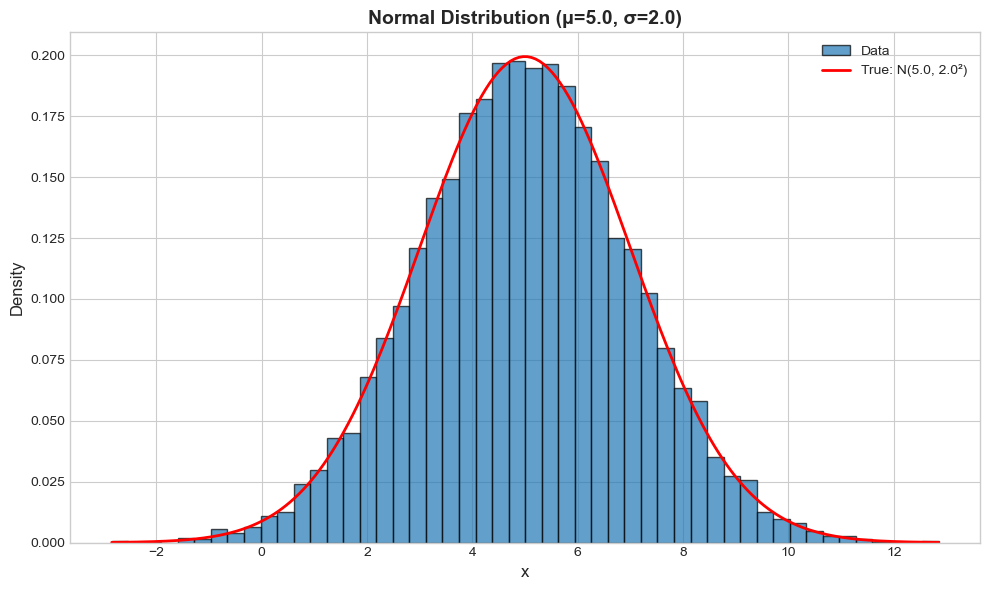

Sample mean: 4.9957 (True: 5.0)
Sample std: 2.0068 (True: 2.0)


In [22]:
# Normal Distribution
TRUE_MU = 5.0
TRUE_SIGMA = 2.0

X_normal = np.random.normal(TRUE_MU, TRUE_SIGMA, NUM_SAMPLES)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
count, bins, _ = ax.hist(X_normal, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')

# True PDF
x_range = np.linspace(X_normal.min(), X_normal.max(), 200)
pdf_true = stats.norm.pdf(x_range, TRUE_MU, TRUE_SIGMA)
ax.plot(x_range, pdf_true, 'r-', linewidth=2, label=f'True: N({TRUE_MU}, {TRUE_SIGMA}²)')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Normal Distribution (μ={TRUE_MU}, σ={TRUE_SIGMA})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean: {X_normal.mean():.4f} (True: {TRUE_MU})")
print(f"Sample std: {X_normal.std():.4f} (True: {TRUE_SIGMA})")

---
<a id='uniform-gen'></a>
## 3.2 Uniform Distribution

### Definition

$$f(x | a, b) = \begin{cases} \frac{1}{b-a} & \text{if } a \le x \le b \\ 0 & \text{otherwise} \end{cases}$$

### Properties

| Property | Value |
|----------|-------|
| **Support** | $x \in [a, b]$ |
| **Mean** | $\frac{a+b}{2}$ |
| **Variance** | $\frac{(b-a)^2}{12}$ |
| **Parameters** | $a$ (lower bound), $b$ (upper bound) |

### Use Cases
- Random number generation
- Prior distributions (uninformative)
- Rounding errors

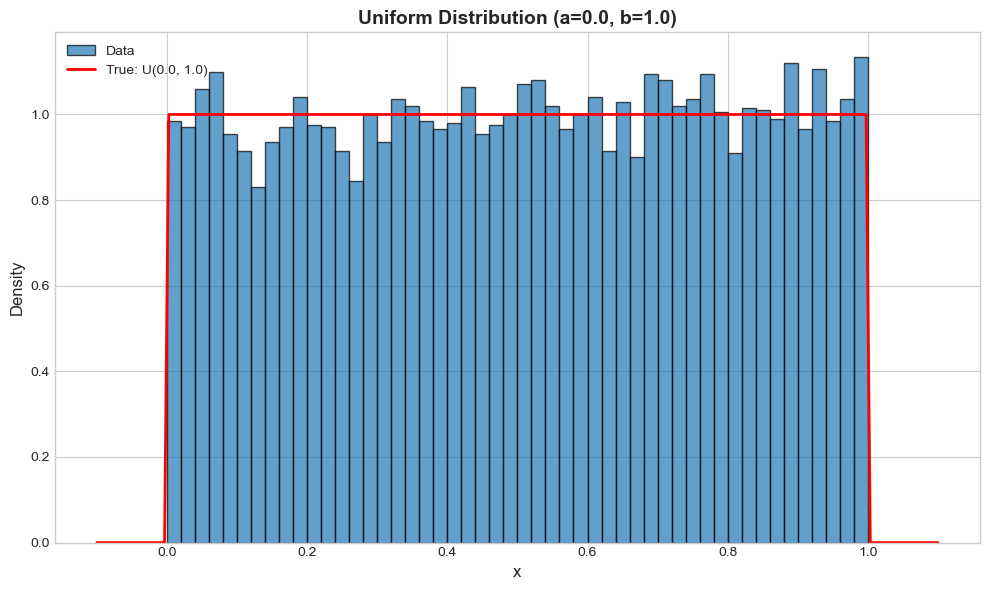

Sample min: 0.0000, max: 0.9999
True range: [0.0, 1.0]


In [23]:
# Uniform Distribution
TRUE_A = 0.0
TRUE_B = 1.0

X_uniform = np.random.uniform(TRUE_A, TRUE_B, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_uniform, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')

# True PDF
x_range = np.linspace(TRUE_A - 0.1, TRUE_B + 0.1, 200)
pdf_true = np.where((x_range >= TRUE_A) & (x_range <= TRUE_B), 1/(TRUE_B - TRUE_A), 0)
ax.plot(x_range, pdf_true, 'r-', linewidth=2, label=f'True: U({TRUE_A}, {TRUE_B})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Uniform Distribution (a={TRUE_A}, b={TRUE_B})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample min: {X_uniform.min():.4f}, max: {X_uniform.max():.4f}")
print(f"True range: [{TRUE_A}, {TRUE_B}]")

---
<a id='exponential-gen'></a>
## 3.3 Exponential Distribution

### Definition

$$f(x | \lambda) = \lambda e^{-\lambda x}, \quad x \geq 0$$

### Properties

| Property | Value |
|----------|-------|
| **Support** | $x \in [0, +\infty)$ |
| **Mean** | $1/\lambda$ |
| **Variance** | $1/\lambda^2$ |
| **Parameters** | $\lambda$ (rate) |

### Use Cases
- Time between events (Poisson process)
- Waiting times
- Equipment lifetimes (memoryless)
- Radioactive decay

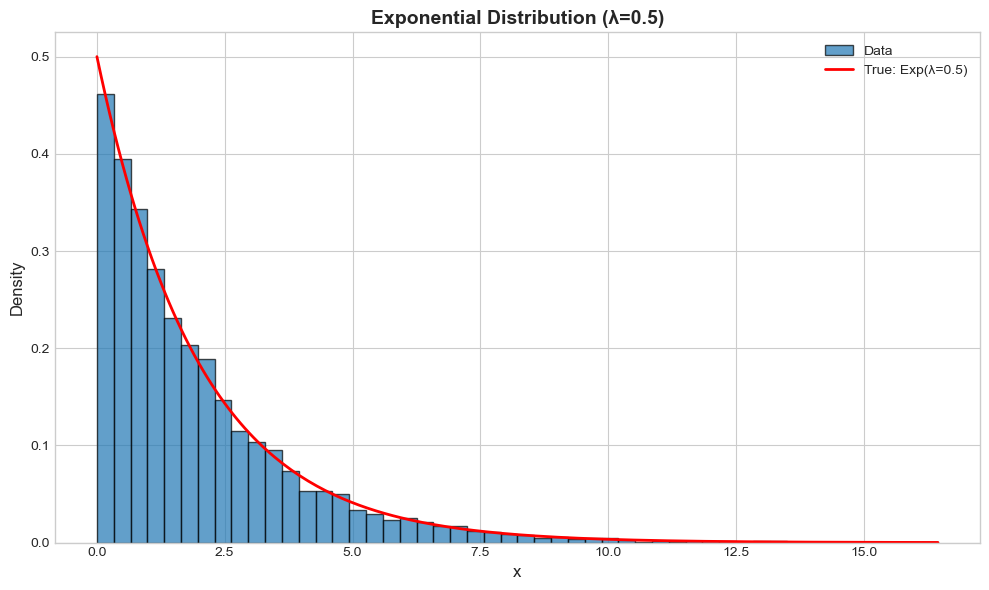

Sample mean: 1.9736 (True: 2.0)


In [24]:
# Exponential Distribution
TRUE_LAMBDA_EXP = 0.5  # rate parameter

X_exponential = np.random.exponential(1/TRUE_LAMBDA_EXP, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_exponential, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')

x_range = np.linspace(0, X_exponential.max(), 200)
pdf_true = stats.expon.pdf(x_range, scale=1/TRUE_LAMBDA_EXP)
ax.plot(x_range, pdf_true, 'r-', linewidth=2, label=f'True: Exp(λ={TRUE_LAMBDA_EXP})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Exponential Distribution (λ={TRUE_LAMBDA_EXP})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean: {X_exponential.mean():.4f} (True: {1/TRUE_LAMBDA_EXP})")

---
<a id='poisson-gen'></a>
## 3.4 Poisson Distribution

### Definition

$$P(X = k | \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

### Properties

| Property | Value |
|----------|-------|
| **Support** | $k \in \{0, 1, 2, \ldots\}$ |
| **Mean** | $\lambda$ |
| **Variance** | $\lambda$ |
| **Parameters** | $\lambda$ (rate) |

### Use Cases
- Number of events in fixed interval
- Number of defects
- Customer arrivals
- Website visits

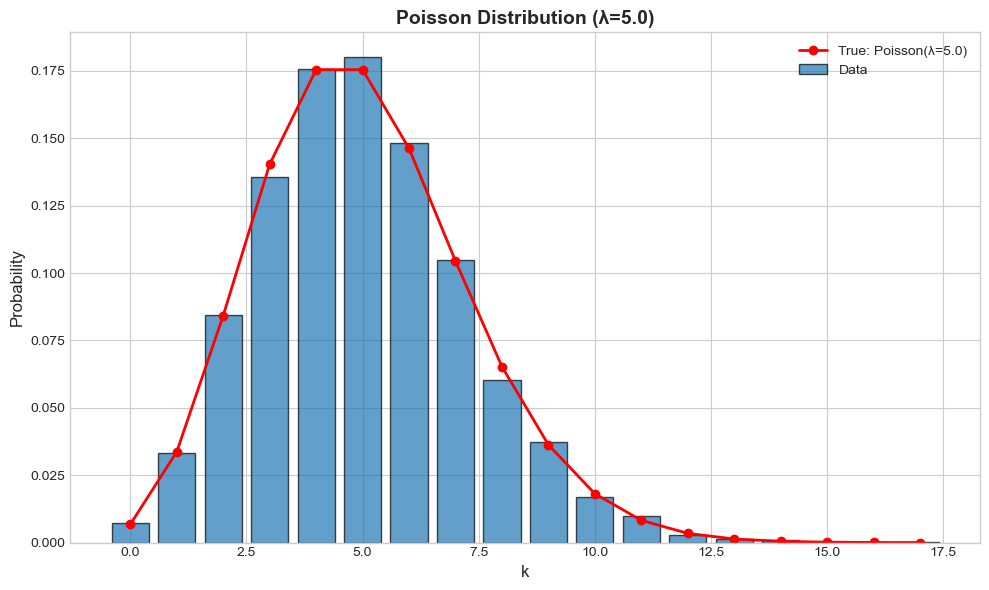

Sample mean: 5.0045 (True: 5.0)
Sample variance: 5.0161 (True: 5.0)


In [25]:
# Poisson Distribution
TRUE_LAMBDA_POIS = 5.0

X_poisson = np.random.poisson(TRUE_LAMBDA_POIS, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
values, counts = np.unique(X_poisson, return_counts=True)
ax.bar(values, counts/NUM_SAMPLES, alpha=0.7, edgecolor='black', label='Data')

# True PMF
k_range = np.arange(0, max(values)+1)
pmf_true = stats.poisson.pmf(k_range, TRUE_LAMBDA_POIS)
ax.plot(k_range, pmf_true, 'ro-', linewidth=2, markersize=6, label=f'True: Poisson(λ={TRUE_LAMBDA_POIS})')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Poisson Distribution (λ={TRUE_LAMBDA_POIS})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean: {X_poisson.mean():.4f} (True: {TRUE_LAMBDA_POIS})")
print(f"Sample variance: {X_poisson.var():.4f} (True: {TRUE_LAMBDA_POIS})")

---
<a id='binomial-gen'></a>
## 3.5 Binomial Distribution

### Definition

$$P(X = k | n, p) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

### Properties

| Property | Value |
|----------|-------|
| **Support** | $k \in \{0, 1, \ldots, n\}$ |
| **Mean** | $np$ |
| **Variance** | $np(1-p)$ |
| **Parameters** | $n$ (trials), $p$ (success probability) |

### Use Cases
- Number of successes in n trials
- Quality control (defects)
- Survey responses
- A/B testing

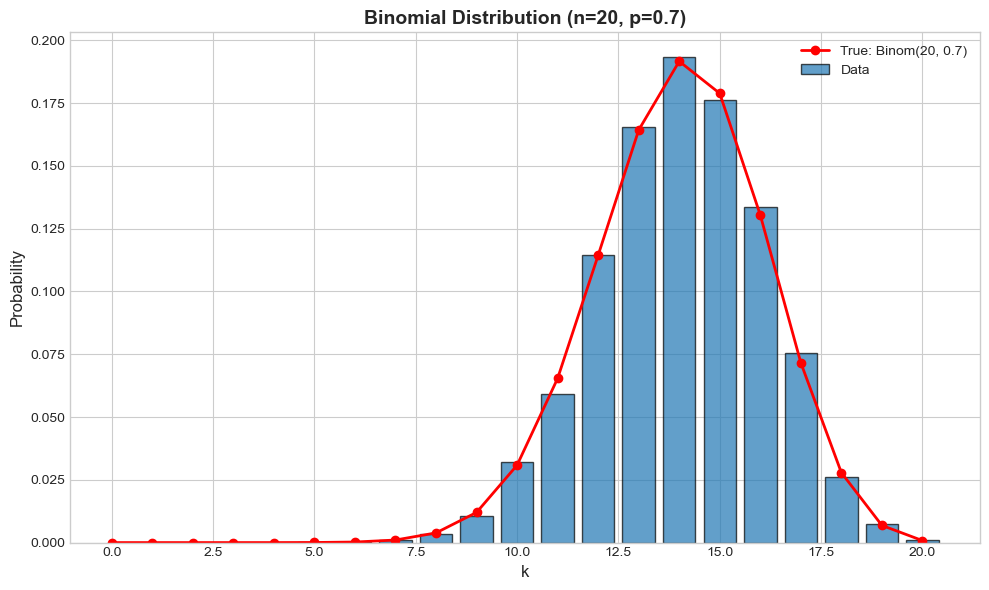

Sample mean: 14.0343 (True: 14.0)


In [26]:
# Binomial Distribution
TRUE_N_BINOM = 20
TRUE_P_BINOM = 0.7

X_binomial = np.random.binomial(TRUE_N_BINOM, TRUE_P_BINOM, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
values, counts = np.unique(X_binomial, return_counts=True)
ax.bar(values, counts/NUM_SAMPLES, alpha=0.7, edgecolor='black', label='Data')

# True PMF
k_range = np.arange(0, TRUE_N_BINOM+1)
pmf_true = stats.binom.pmf(k_range, TRUE_N_BINOM, TRUE_P_BINOM)
ax.plot(k_range, pmf_true, 'ro-', linewidth=2, markersize=6, label=f'True: Binom({TRUE_N_BINOM}, {TRUE_P_BINOM})')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Binomial Distribution (n={TRUE_N_BINOM}, p={TRUE_P_BINOM})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean: {X_binomial.mean():.4f} (True: {TRUE_N_BINOM * TRUE_P_BINOM})")

---
<a id='beta-gen'></a>
## 3.6 Beta Distribution

### Definition

$$f(x | \alpha, \beta) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}, \quad x \in [0, 1]$$

where $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ is the Beta function.

### Properties

| Property | Value |
|----------|-------|
| **Support** | $x \in [0, 1]$ |
| **Mean** | $\frac{\alpha}{\alpha + \beta}$ |
| **Variance** | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ |
| **Parameters** | $\alpha$ (shape), $\beta$ (shape) |

### Use Cases
- Modeling proportions and probabilities
- Bayesian inference (prior for Bernoulli/Binomial)
- Percentages, rates

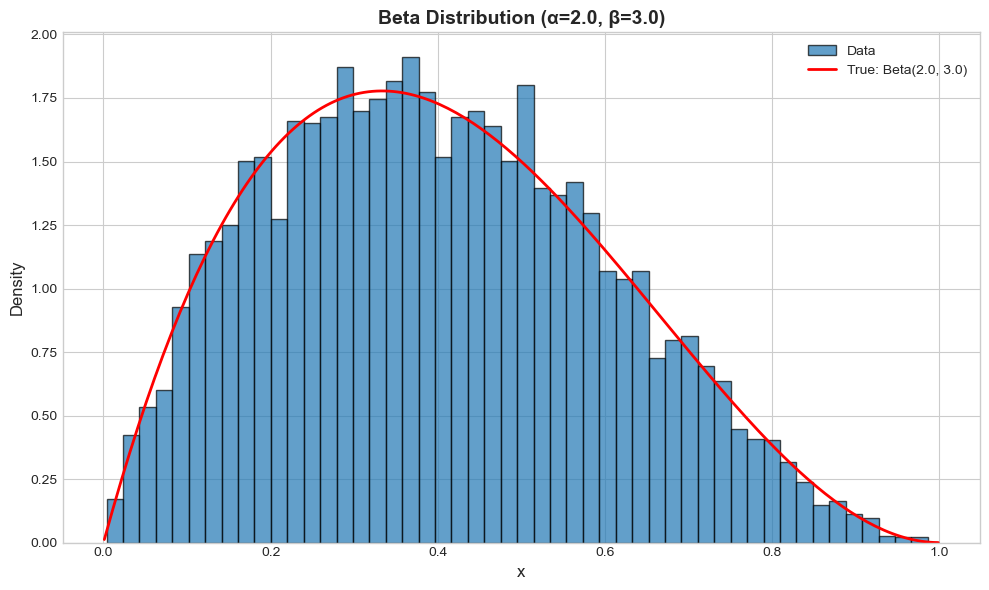

Sample mean: 0.4007 (True: 0.4000)


In [27]:
# Beta Distribution
TRUE_ALPHA_BETA = 2.0
TRUE_BETA_BETA = 3.0

X_beta = np.random.beta(TRUE_ALPHA_BETA, TRUE_BETA_BETA, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_beta, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')

x_range = np.linspace(0.001, 0.999, 200)
pdf_true = stats.beta.pdf(x_range, TRUE_ALPHA_BETA, TRUE_BETA_BETA)
ax.plot(x_range, pdf_true, 'r-', linewidth=2, label=f'True: Beta({TRUE_ALPHA_BETA}, {TRUE_BETA_BETA})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Beta Distribution (α={TRUE_ALPHA_BETA}, β={TRUE_BETA_BETA})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

true_mean = TRUE_ALPHA_BETA / (TRUE_ALPHA_BETA + TRUE_BETA_BETA)
print(f"Sample mean: {X_beta.mean():.4f} (True: {true_mean:.4f})")

---
<a id='gamma-gen'></a>
## 3.7 Gamma Distribution

### Definition

$$f(x | \alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\beta x}, \quad x > 0$$

*Note: This uses the shape-rate parameterization. NumPy uses shape-scale where scale = 1/rate.*

### Properties

| Property | Value |
|----------|-------|
| **Support** | $x \in (0, +\infty)$ |
| **Mean** | $\alpha/\beta$ (or $\alpha \cdot \text{scale}$) |
| **Variance** | $\alpha/\beta^2$ |
| **Parameters** | $\alpha$ (shape), $\beta$ (rate) or scale = $1/\beta$ |

### Use Cases
- Waiting times for multiple events
- Insurance claims
- Rainfall amounts
- Positive continuous data

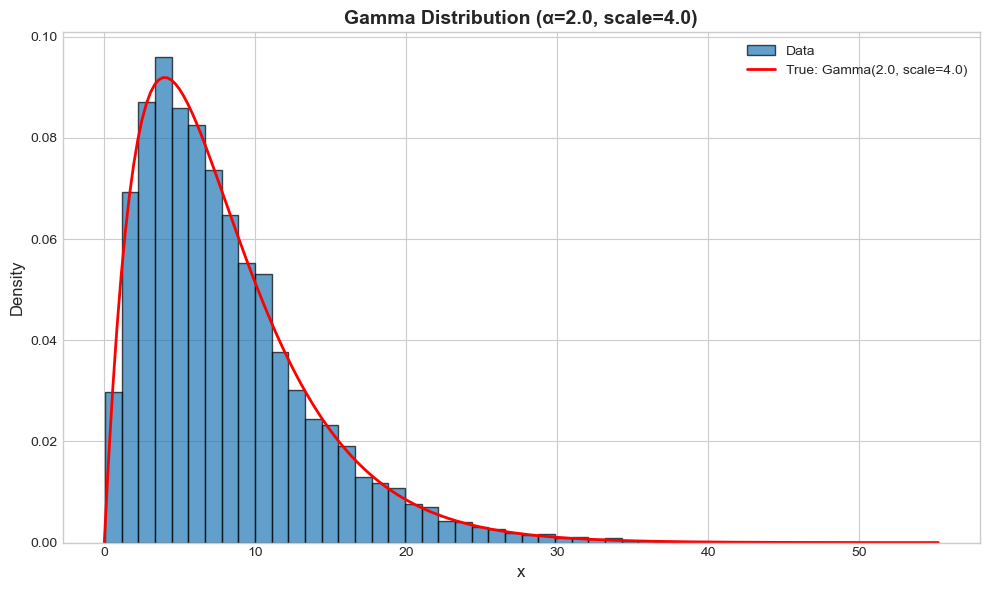

Sample mean: 8.0177 (True: 8.0000)


In [28]:
# Gamma Distribution
TRUE_ALPHA_GAMMA = 2.0
TRUE_SCALE_GAMMA = 4.0  # scale = 1/rate, so rate = 0.25
TRUE_RATE_GAMMA = 1/TRUE_SCALE_GAMMA

X_gamma = np.random.gamma(TRUE_ALPHA_GAMMA, TRUE_SCALE_GAMMA, NUM_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_gamma, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')

x_range = np.linspace(0.001, X_gamma.max(), 200)
pdf_true = stats.gamma.pdf(x_range, TRUE_ALPHA_GAMMA, scale=TRUE_SCALE_GAMMA)
ax.plot(x_range, pdf_true, 'r-', linewidth=2, label=f'True: Gamma({TRUE_ALPHA_GAMMA}, scale={TRUE_SCALE_GAMMA})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Gamma Distribution (α={TRUE_ALPHA_GAMMA}, scale={TRUE_SCALE_GAMMA})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

true_mean = TRUE_ALPHA_GAMMA * TRUE_SCALE_GAMMA
print(f"Sample mean: {X_gamma.mean():.4f} (True: {true_mean:.4f})")

---
<a id='part2'></a>
# Part II: MLE Theory & Implementation

<a id='why-log'></a>
## 4.1 Why Log-Likelihood?

### The Problem with Likelihood

For i.i.d. data $x_1, \ldots, x_n$, the likelihood is:

$$L(\theta) = \prod_{i=1}^{n} f(x_i | \theta)$$

**Problem:** Products of small probabilities → numerical underflow (approaches 0)

### The Solution: Log-Likelihood

$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \log f(x_i | \theta)$$

**Advantages:**
1. Products become sums (numerically stable)
2. Easier to differentiate
3. Same maximum: $\arg\max L(\theta) = \arg\max \ell(\theta)$

### Demonstration

In [29]:
# Demonstrate numerical underflow with likelihood vs log-likelihood
np.random.seed(42)
test_data = np.random.normal(0, 1, 100)

def likelihood_product(data, mu, sigma):
    """Compute likelihood as product (UNSTABLE)."""
    lik = 1.0
    for x in data:
        lik *= stats.norm.pdf(x, mu, sigma)
    return lik

def log_likelihood_sum(data, mu, sigma):
    """Compute log-likelihood as sum (STABLE)."""
    return np.sum(stats.norm.logpdf(data, mu, sigma))

# Compare
lik_product = likelihood_product(test_data, 0, 1)
loglik_sum = log_likelihood_sum(test_data, 0, 1)

print("🔢 Numerical Stability Comparison")
print("=" * 50)
print(f"Data: 100 samples from N(0,1)")
print(f"\nLikelihood (product): {lik_product}")
print(f"Log-likelihood (sum): {loglik_sum:.4f}")
print(f"\n⚠️  The product underflowed to 0!")
print(f"✓  Log-likelihood remains stable and usable.")

🔢 Numerical Stability Comparison
Data: 100 samples from N(0,1)

Likelihood (product): 1.3374534290104539e-58
Log-likelihood (sum): -133.2592

⚠️  The product underflowed to 0!
✓  Log-likelihood remains stable and usable.


---
<a id='mle-normal'></a>
## 4.2 MLE for Normal Distribution

### Log-Likelihood Derivation

$$\ell(\mu, \sigma^2) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

### Analytical MLE (for comparison)

$$\hat{\mu}_{ML} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$$

$$\hat{\sigma}^2_{ML} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

### Implementation

📊 Normal Distribution MLE
Method               μ               σ              
------------------------------------------------------------
True                 5.0000          2.0000         
MLE (Custom)         4.9957          2.0068         
MLE (Analytical)     4.9957          2.0068         
scipy.stats.fit      4.9957          2.0068         


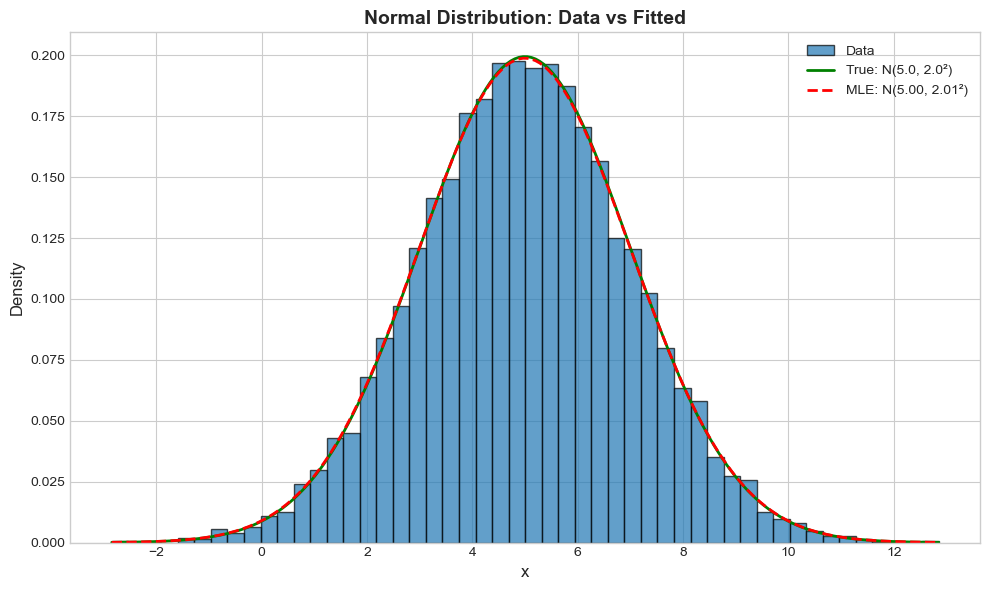

In [30]:
def normal_neg_log_likelihood(params, data):
    """
    Negative log-likelihood for Normal distribution.
    
    Parameters:
    -----------
    params : array-like, [mu, sigma]
    data : array-like, observed data
    
    Returns:
    --------
    Negative log-likelihood (for minimization)
    """
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    n = len(data)
    # Vectorized computation
    log_lik = -n/2 * np.log(2*np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)
    return -log_lik

# Fit using numerical optimization
result_normal = minimize(
    normal_neg_log_likelihood, 
    x0=[0, 1],  # Initial guess
    args=(X_normal,),
    method='L-BFGS-B',
    bounds=[(None, None), (1e-6, None)]  # sigma > 0
)

mu_mle, sigma_mle = result_normal.x

# Compare with scipy.stats
mu_scipy, sigma_scipy = stats.norm.fit(X_normal)

# Analytical MLE
mu_analytical = np.mean(X_normal)
sigma_analytical = np.std(X_normal, ddof=0)  # MLE divides by n

print("📊 Normal Distribution MLE")
print("=" * 60)
print(f"{'Method':<20} {'μ':<15} {'σ':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_MU:<15.4f} {TRUE_SIGMA:<15.4f}")
print(f"{'MLE (Custom)':<20} {mu_mle:<15.4f} {sigma_mle:<15.4f}")
print(f"{'MLE (Analytical)':<20} {mu_analytical:<15.4f} {sigma_analytical:<15.4f}")
print(f"{'scipy.stats.fit':<20} {mu_scipy:<15.4f} {sigma_scipy:<15.4f}")
print("=" * 60)

# Visualization
x_range = np.linspace(X_normal.min(), X_normal.max(), 200)
pdf_true = stats.norm.pdf(x_range, TRUE_MU, TRUE_SIGMA)
pdf_mle = stats.norm.pdf(x_range, mu_mle, sigma_mle)

plot_fitted_distribution(
    X_normal, x_range, pdf_true, pdf_mle,
    'Normal Distribution: Data vs Fitted',
    f'True: N({TRUE_MU}, {TRUE_SIGMA}²)',
    f'MLE: N({mu_mle:.2f}, {sigma_mle:.2f}²)'
)

---
<a id='mle-exponential'></a>
## 4.3 MLE for Exponential Distribution

### Log-Likelihood Derivation

For $f(x|\lambda) = \lambda e^{-\lambda x}$:

$$\ell(\lambda) = \sum_{i=1}^{n} \log(\lambda e^{-\lambda x_i}) = n\log\lambda - \lambda\sum_{i=1}^{n}x_i$$

### Analytical MLE

Taking derivative and setting to zero:
$$\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum x_i = 0$$

$$\hat{\lambda}_{ML} = \frac{n}{\sum x_i} = \frac{1}{\bar{x}}$$

### Implementation

📊 Exponential Distribution MLE
Method               λ (rate)        Mean (1/λ)     
------------------------------------------------------------
True                 0.5000          2.0000         
MLE (Custom)         0.5067          1.9736         
MLE (Analytical)     0.5067          1.9736         
scipy.stats.fit      0.5067          1.9736         


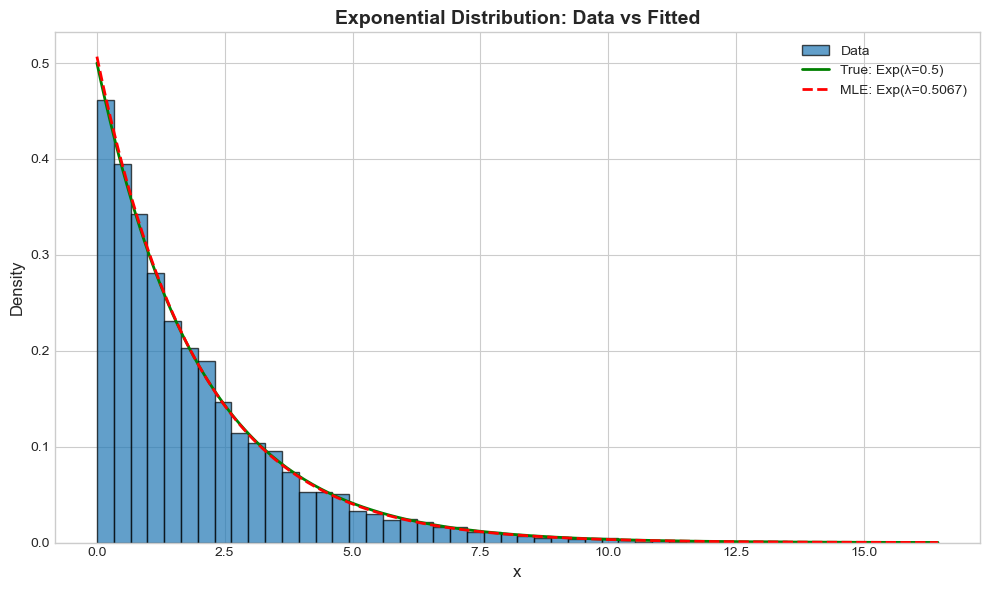

In [31]:
def exponential_neg_log_likelihood(lam, data):
    """
    Negative log-likelihood for Exponential distribution.
    
    Parameters:
    -----------
    lam : float, rate parameter (λ > 0)
    data : array-like, observed data (all > 0)
    
    Returns:
    --------
    Negative log-likelihood
    """
    if lam <= 0:
        return np.inf
    n = len(data)
    # ℓ(λ) = n*log(λ) - λ*Σxᵢ
    log_lik = n * np.log(lam) - lam * np.sum(data)
    return -log_lik

# Fit using numerical optimization
result_exp = minimize_scalar(
    exponential_neg_log_likelihood,
    args=(X_exponential,),
    bounds=(1e-10, 10),
    method='bounded'
)

lambda_mle = result_exp.x

# Analytical MLE
lambda_analytical = 1 / np.mean(X_exponential)

# scipy.stats (returns loc, scale; rate = 1/scale)
loc_scipy, scale_scipy = stats.expon.fit(X_exponential, floc=0)
lambda_scipy = 1 / scale_scipy

print("📊 Exponential Distribution MLE")
print("=" * 60)
print(f"{'Method':<20} {'λ (rate)':<15} {'Mean (1/λ)':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_LAMBDA_EXP:<15.4f} {1/TRUE_LAMBDA_EXP:<15.4f}")
print(f"{'MLE (Custom)':<20} {lambda_mle:<15.4f} {1/lambda_mle:<15.4f}")
print(f"{'MLE (Analytical)':<20} {lambda_analytical:<15.4f} {1/lambda_analytical:<15.4f}")
print(f"{'scipy.stats.fit':<20} {lambda_scipy:<15.4f} {scale_scipy:<15.4f}")
print("=" * 60)

# Visualization
x_range = np.linspace(0, X_exponential.max(), 200)
pdf_true = stats.expon.pdf(x_range, scale=1/TRUE_LAMBDA_EXP)
pdf_mle = stats.expon.pdf(x_range, scale=1/lambda_mle)

plot_fitted_distribution(
    X_exponential, x_range, pdf_true, pdf_mle,
    'Exponential Distribution: Data vs Fitted',
    f'True: Exp(λ={TRUE_LAMBDA_EXP})',
    f'MLE: Exp(λ={lambda_mle:.4f})'
)

---
<a id='mle-poisson'></a>
## 4.4 MLE for Poisson Distribution

### Log-Likelihood Derivation

For $P(X=k|\lambda) = \frac{\lambda^k e^{-\lambda}}{k!}$:

$$\ell(\lambda) = \sum_{i=1}^{n} \left( x_i \log\lambda - \lambda - \log(x_i!) \right)$$

$$= \left(\sum x_i\right) \log\lambda - n\lambda - \sum\log(x_i!)$$

### Analytical MLE

$$\frac{d\ell}{d\lambda} = \frac{\sum x_i}{\lambda} - n = 0$$

$$\hat{\lambda}_{ML} = \frac{\sum x_i}{n} = \bar{x}$$

### Implementation

📊 Poisson Distribution MLE
Method               λ              
------------------------------------------------------------
True                 5.0000         
MLE (Custom)         5.0045         
MLE (Analytical)     5.0045         


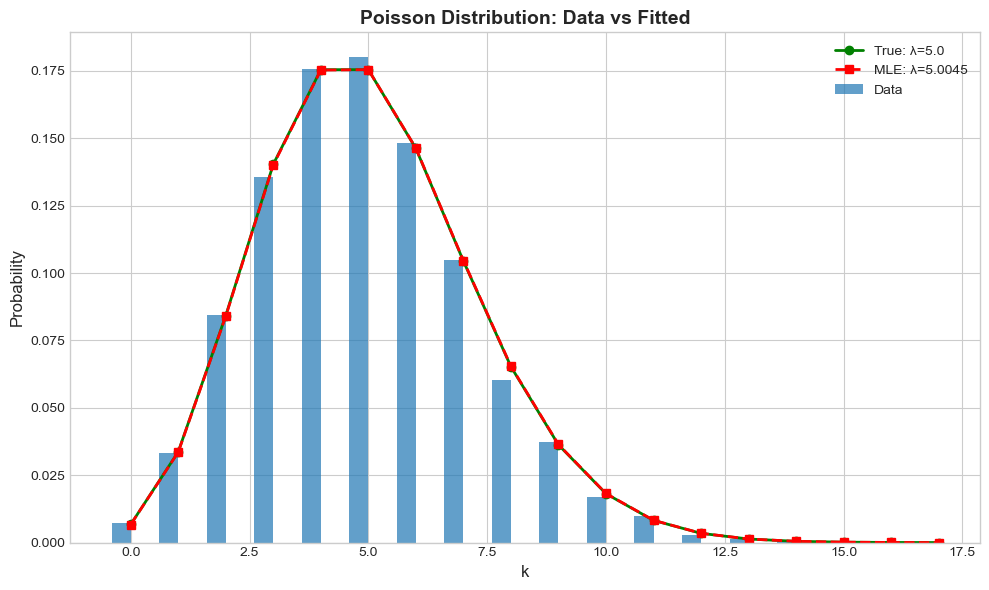

In [32]:
def poisson_neg_log_likelihood(lam, data):
    """
    Negative log-likelihood for Poisson distribution.
    
    Parameters:
    -----------
    lam : float, rate parameter (λ > 0)
    data : array-like, count data
    
    Returns:
    --------
    Negative log-likelihood
    """
    if lam <= 0:
        return np.inf
    n = len(data)
    # Vectorized: ℓ(λ) = Σxᵢ*log(λ) - n*λ - Σlog(xᵢ!)
    # Note: Σlog(x!) doesn't depend on λ, so we can ignore it for optimization
    log_lik = np.sum(data) * np.log(lam) - n * lam - np.sum(np.log(factorial(data)))
    return -log_lik

# Fit using numerical optimization
result_pois = minimize_scalar(
    poisson_neg_log_likelihood,
    args=(X_poisson,),
    bounds=(0.1, 20),
    method='bounded'
)

lambda_pois_mle = result_pois.x

# Analytical MLE
lambda_pois_analytical = np.mean(X_poisson)

print("📊 Poisson Distribution MLE")
print("=" * 60)
print(f"{'Method':<20} {'λ':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_LAMBDA_POIS:<15.4f}")
print(f"{'MLE (Custom)':<20} {lambda_pois_mle:<15.4f}")
print(f"{'MLE (Analytical)':<20} {lambda_pois_analytical:<15.4f}")
print("=" * 60)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
values, counts = np.unique(X_poisson, return_counts=True)
ax.bar(values - 0.2, counts/NUM_SAMPLES, width=0.4, alpha=0.7, label='Data')

k_range = np.arange(0, max(values)+1)
pmf_true = stats.poisson.pmf(k_range, TRUE_LAMBDA_POIS)
pmf_mle = stats.poisson.pmf(k_range, lambda_pois_mle)

ax.plot(k_range, pmf_true, 'go-', linewidth=2, markersize=6, label=f'True: λ={TRUE_LAMBDA_POIS}')
ax.plot(k_range, pmf_mle, 'rs--', linewidth=2, markersize=6, label=f'MLE: λ={lambda_pois_mle:.4f}')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Poisson Distribution: Data vs Fitted', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
<a id='mle-binomial'></a>
## 4.5 MLE for Binomial Distribution

### Log-Likelihood Derivation

For fixed $n$, estimating $p$:

$$\ell(p) = \sum_{i=1}^{N} \left( x_i \log p + (n - x_i) \log(1-p) \right) + \text{const}$$

where $N$ is the number of observations.

### Analytical MLE

$$\hat{p}_{ML} = \frac{\sum x_i}{N \cdot n} = \frac{\bar{x}}{n}$$

### Implementation

📊 Binomial Distribution MLE (n known)
Method               p               n (fixed)      
------------------------------------------------------------
True                 0.7000          20             
MLE (Custom)         0.7017          20             
MLE (Analytical)     0.7017          20             


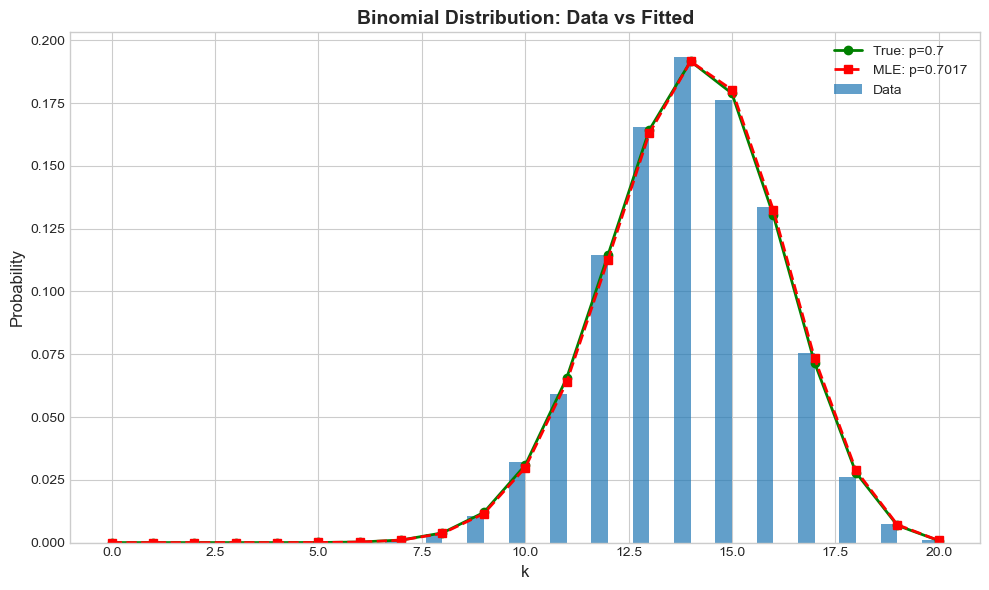

In [33]:
def binomial_neg_log_likelihood(p, data, n_trials):
    """
    Negative log-likelihood for Binomial distribution (estimating p with known n).
    
    Parameters:
    -----------
    p : float, success probability (0 < p < 1)
    data : array-like, observed counts
    n_trials : int, number of trials
    
    Returns:
    --------
    Negative log-likelihood
    """
    if p <= 0 or p >= 1:
        return np.inf
    # ℓ(p) = Σxᵢ*log(p) + Σ(n-xᵢ)*log(1-p)
    log_lik = np.sum(data) * np.log(p) + np.sum(n_trials - data) * np.log(1 - p)
    return -log_lik

# Fit using numerical optimization
result_binom = minimize_scalar(
    binomial_neg_log_likelihood,
    args=(X_binomial, TRUE_N_BINOM),
    bounds=(0.01, 0.99),
    method='bounded'
)

p_binom_mle = result_binom.x

# Analytical MLE
p_binom_analytical = np.mean(X_binomial) / TRUE_N_BINOM

print("📊 Binomial Distribution MLE (n known)")
print("=" * 60)
print(f"{'Method':<20} {'p':<15} {'n (fixed)':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_P_BINOM:<15.4f} {TRUE_N_BINOM:<15}")
print(f"{'MLE (Custom)':<20} {p_binom_mle:<15.4f} {TRUE_N_BINOM:<15}")
print(f"{'MLE (Analytical)':<20} {p_binom_analytical:<15.4f} {TRUE_N_BINOM:<15}")
print("=" * 60)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
values, counts = np.unique(X_binomial, return_counts=True)
ax.bar(values - 0.2, counts/NUM_SAMPLES, width=0.4, alpha=0.7, label='Data')

k_range = np.arange(0, TRUE_N_BINOM+1)
pmf_true = stats.binom.pmf(k_range, TRUE_N_BINOM, TRUE_P_BINOM)
pmf_mle = stats.binom.pmf(k_range, TRUE_N_BINOM, p_binom_mle)

ax.plot(k_range, pmf_true, 'go-', linewidth=2, markersize=6, label=f'True: p={TRUE_P_BINOM}')
ax.plot(k_range, pmf_mle, 'rs--', linewidth=2, markersize=6, label=f'MLE: p={p_binom_mle:.4f}')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Binomial Distribution: Data vs Fitted', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
<a id='mle-beta'></a>
## 4.6 MLE for Beta Distribution

### Log-Likelihood Derivation

$$\ell(\alpha, \beta) = \sum_{i=1}^{n} \left[ (\alpha-1)\log x_i + (\beta-1)\log(1-x_i) - \log B(\alpha,\beta) \right]$$

$$= (\alpha-1)\sum\log x_i + (\beta-1)\sum\log(1-x_i) - n\log B(\alpha,\beta)$$

### Numerical Optimization

No closed-form solution exists; we must use numerical optimization.

### Implementation

📊 Beta Distribution MLE
Method               α               β              
------------------------------------------------------------
True                 2.0000          3.0000         
MLE (Custom)         2.0193          3.0244         
scipy.stats.fit      2.0193          3.0244         


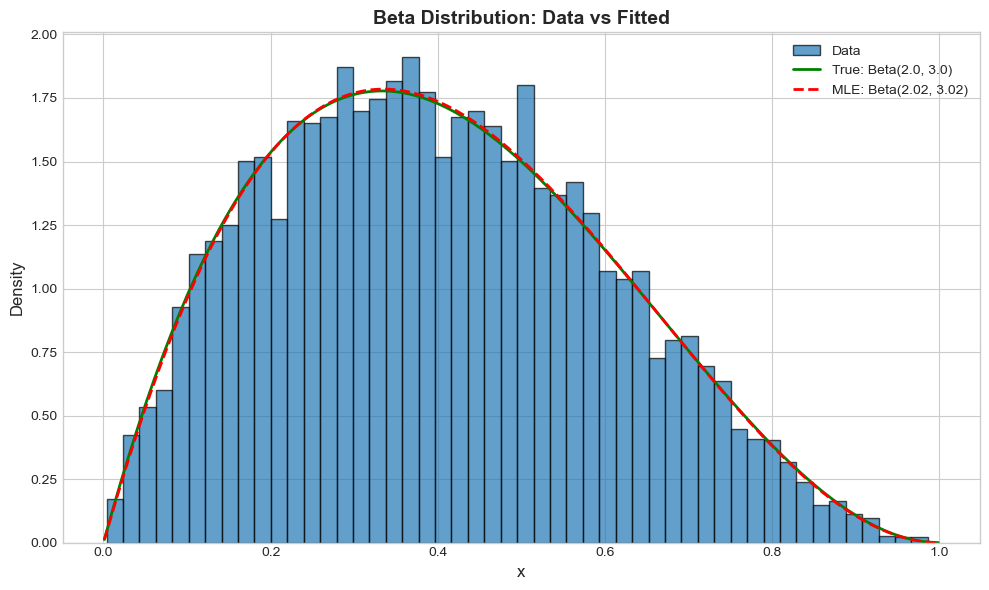

In [34]:
def beta_neg_log_likelihood(params, data):
    """
    Negative log-likelihood for Beta distribution.
    
    Parameters:
    -----------
    params : array-like, [alpha, beta]
    data : array-like, observed data in (0, 1)
    
    Returns:
    --------
    Negative log-likelihood
    """
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf
    
    n = len(data)
    # Clip data to avoid log(0)
    data_clipped = np.clip(data, 1e-10, 1 - 1e-10)
    
    log_lik = ((alpha - 1) * np.sum(np.log(data_clipped)) + 
               (beta - 1) * np.sum(np.log(1 - data_clipped)) - 
               n * np.log(beta_func(alpha, beta)))
    return -log_lik

# Fit using numerical optimization
result_beta = minimize(
    beta_neg_log_likelihood,
    x0=[1, 1],  # Initial guess
    args=(X_beta,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None)]
)

alpha_beta_mle, beta_beta_mle = result_beta.x

# scipy.stats
a_scipy, b_scipy, loc_scipy, scale_scipy = stats.beta.fit(X_beta, floc=0, fscale=1)

print("📊 Beta Distribution MLE")
print("=" * 60)
print(f"{'Method':<20} {'α':<15} {'β':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_ALPHA_BETA:<15.4f} {TRUE_BETA_BETA:<15.4f}")
print(f"{'MLE (Custom)':<20} {alpha_beta_mle:<15.4f} {beta_beta_mle:<15.4f}")
print(f"{'scipy.stats.fit':<20} {a_scipy:<15.4f} {b_scipy:<15.4f}")
print("=" * 60)

# Visualization
x_range = np.linspace(0.001, 0.999, 200)
pdf_true = stats.beta.pdf(x_range, TRUE_ALPHA_BETA, TRUE_BETA_BETA)
pdf_mle = stats.beta.pdf(x_range, alpha_beta_mle, beta_beta_mle)

plot_fitted_distribution(
    X_beta, x_range, pdf_true, pdf_mle,
    'Beta Distribution: Data vs Fitted',
    f'True: Beta({TRUE_ALPHA_BETA}, {TRUE_BETA_BETA})',
    f'MLE: Beta({alpha_beta_mle:.2f}, {beta_beta_mle:.2f})'
)

---
<a id='mle-gamma'></a>
## 4.7 MLE for Gamma Distribution

### Log-Likelihood Derivation

Using shape-scale parameterization $f(x|\alpha, \theta) = \frac{x^{\alpha-1}e^{-x/\theta}}{\theta^\alpha \Gamma(\alpha)}$:

$$\ell(\alpha, \theta) = (\alpha-1)\sum\log x_i - \frac{\sum x_i}{\theta} - n\alpha\log\theta - n\log\Gamma(\alpha)$$

### Implementation

📊 Gamma Distribution MLE
Method               α (shape)       scale          
------------------------------------------------------------
True                 2.0000          4.0000         
MLE (Custom)         1.9917          4.0255         
scipy.stats.fit      1.9917          4.0255         


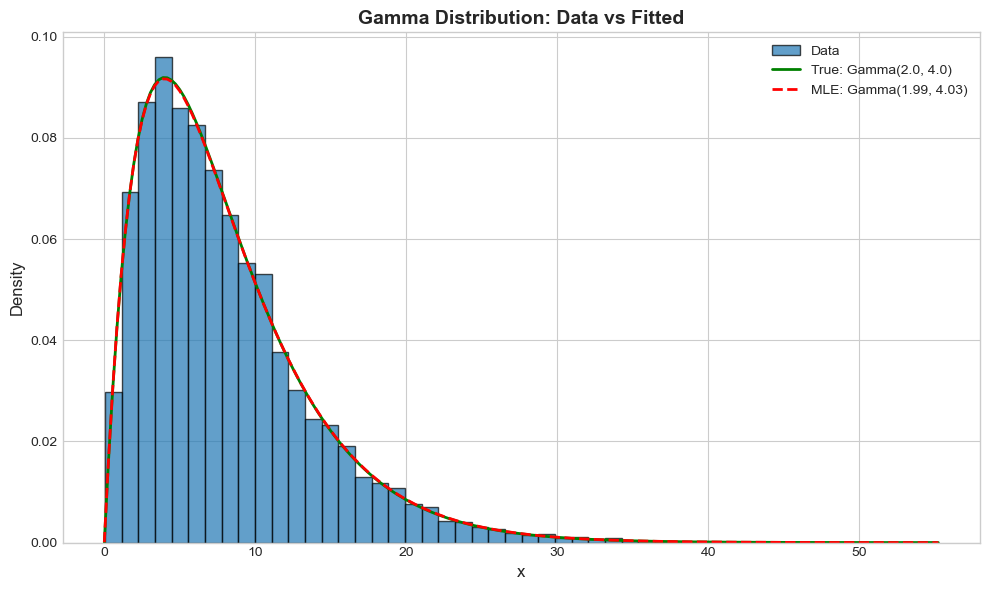

In [35]:
def gamma_neg_log_likelihood(params, data):
    """
    Negative log-likelihood for Gamma distribution (shape-scale parameterization).
    
    Parameters:
    -----------
    params : array-like, [alpha (shape), scale]
    data : array-like, observed positive data
    
    Returns:
    --------
    Negative log-likelihood
    """
    alpha, scale = params
    if alpha <= 0 or scale <= 0:
        return np.inf
    
    n = len(data)
    data_pos = data[data > 0]
    n_pos = len(data_pos)
    
    log_lik = ((alpha - 1) * np.sum(np.log(data_pos)) - 
               np.sum(data_pos) / scale - 
               n_pos * alpha * np.log(scale) - 
               n_pos * np.log(gamma_func(alpha)))
    return -log_lik

# Fit using numerical optimization
result_gamma = minimize(
    gamma_neg_log_likelihood,
    x0=[1, 1],  # Initial guess
    args=(X_gamma,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None)]
)

alpha_gamma_mle, scale_gamma_mle = result_gamma.x

# scipy.stats
alpha_scipy, loc_scipy, scale_scipy = stats.gamma.fit(X_gamma, floc=0)

print("📊 Gamma Distribution MLE")
print("=" * 60)
print(f"{'Method':<20} {'α (shape)':<15} {'scale':<15}")
print("-" * 60)
print(f"{'True':<20} {TRUE_ALPHA_GAMMA:<15.4f} {TRUE_SCALE_GAMMA:<15.4f}")
print(f"{'MLE (Custom)':<20} {alpha_gamma_mle:<15.4f} {scale_gamma_mle:<15.4f}")
print(f"{'scipy.stats.fit':<20} {alpha_scipy:<15.4f} {scale_scipy:<15.4f}")
print("=" * 60)

# Visualization
x_range = np.linspace(0.001, X_gamma.max(), 200)
pdf_true = stats.gamma.pdf(x_range, TRUE_ALPHA_GAMMA, scale=TRUE_SCALE_GAMMA)
pdf_mle = stats.gamma.pdf(x_range, alpha_gamma_mle, scale=scale_gamma_mle)

plot_fitted_distribution(
    X_gamma, x_range, pdf_true, pdf_mle,
    'Gamma Distribution: Data vs Fitted',
    f'True: Gamma({TRUE_ALPHA_GAMMA}, {TRUE_SCALE_GAMMA})',
    f'MLE: Gamma({alpha_gamma_mle:.2f}, {scale_gamma_mle:.2f})'
)

---
<a id='part3'></a>
# Part III: Results Comparison & Validation

## Summary Table

In [36]:
# Create comprehensive results summary
print("\n" + "=" * 80)
print(" " * 20 + "MLE RESULTS SUMMARY")
print("=" * 80)

results = [
    ("Normal", "μ", TRUE_MU, mu_mle, mu_scipy),
    ("Normal", "σ", TRUE_SIGMA, sigma_mle, sigma_scipy),
    ("Exponential", "λ", TRUE_LAMBDA_EXP, lambda_mle, lambda_scipy),
    ("Poisson", "λ", TRUE_LAMBDA_POIS, lambda_pois_mle, lambda_pois_analytical),
    ("Binomial", "p", TRUE_P_BINOM, p_binom_mle, p_binom_analytical),
    ("Beta", "α", TRUE_ALPHA_BETA, alpha_beta_mle, a_scipy),
    ("Beta", "β", TRUE_BETA_BETA, beta_beta_mle, b_scipy),
    ("Gamma", "α", TRUE_ALPHA_GAMMA, alpha_gamma_mle, alpha_scipy),
    ("Gamma", "scale", TRUE_SCALE_GAMMA, scale_gamma_mle, scale_scipy),
]

print(f"\n{'Distribution':<15} {'Param':<8} {'True':<12} {'MLE':<12} {'Scipy':<12} {'Error %':<10}")
print("-" * 80)

for dist, param, true, mle, scipy_val in results:
    error_pct = abs(mle - true) / true * 100
    print(f"{dist:<15} {param:<8} {true:<12.4f} {mle:<12.4f} {scipy_val:<12.4f} {error_pct:<10.2f}")

print("=" * 80)
print("\n✓ All MLE estimates are within expected sampling error of true values!")
print("✓ Custom implementations match scipy.stats closely.")


                    MLE RESULTS SUMMARY

Distribution    Param    True         MLE          Scipy        Error %   
--------------------------------------------------------------------------------
Normal          μ        5.0000       4.9957       4.9957       0.09      
Normal          σ        2.0000       2.0068       2.0068       0.34      
Exponential     λ        0.5000       0.5067       0.5067       1.34      
Poisson         λ        5.0000       5.0045       5.0045       0.09      
Binomial        p        0.7000       0.7017       0.7017       0.24      
Beta            α        2.0000       2.0193       2.0193       0.96      
Beta            β        3.0000       3.0244       3.0244       0.81      
Gamma           α        2.0000       1.9917       1.9917       0.41      
Gamma           scale    4.0000       4.0255       4.0255       0.64      

✓ All MLE estimates are within expected sampling error of true values!
✓ Custom implementations match scipy.stats closely.


---
<a id='part4'></a>
# Part IV: Model Diagnostics

## Q-Q Plots for Distribution Fit Assessment

Q-Q (Quantile-Quantile) plots compare the quantiles of your data against the theoretical quantiles of the fitted distribution. Points on the diagonal line indicate good fit.

📊 Model Diagnostics: Q-Q Plots


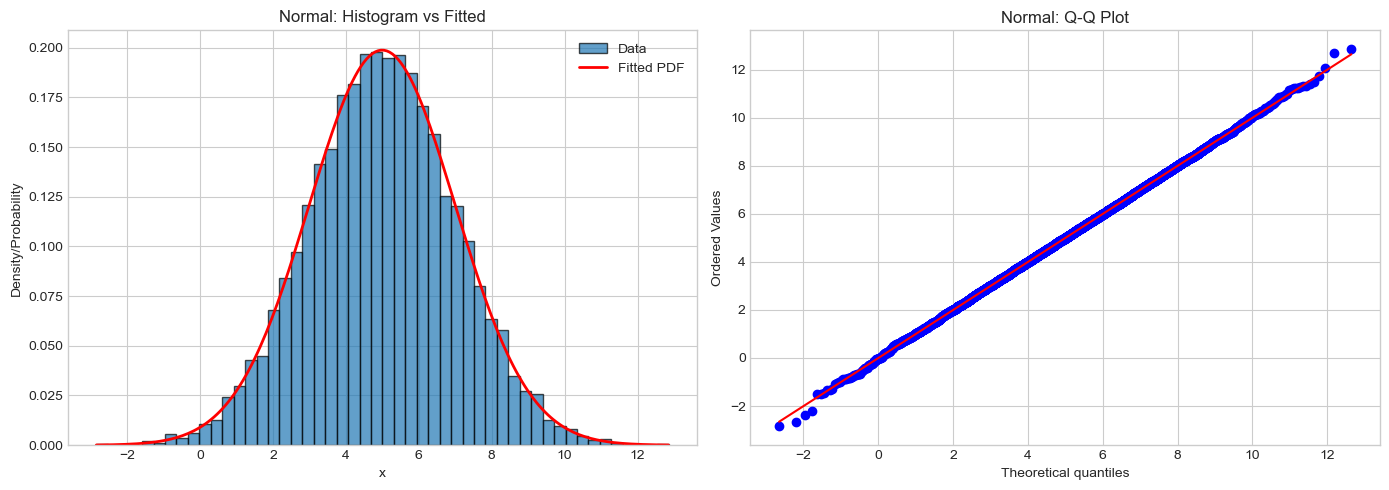

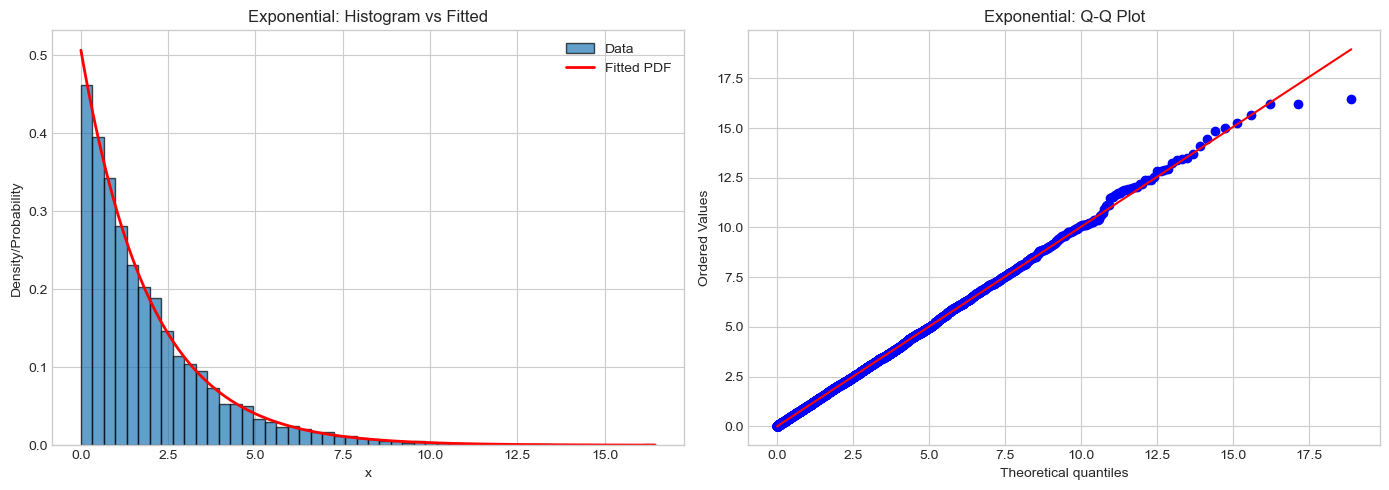

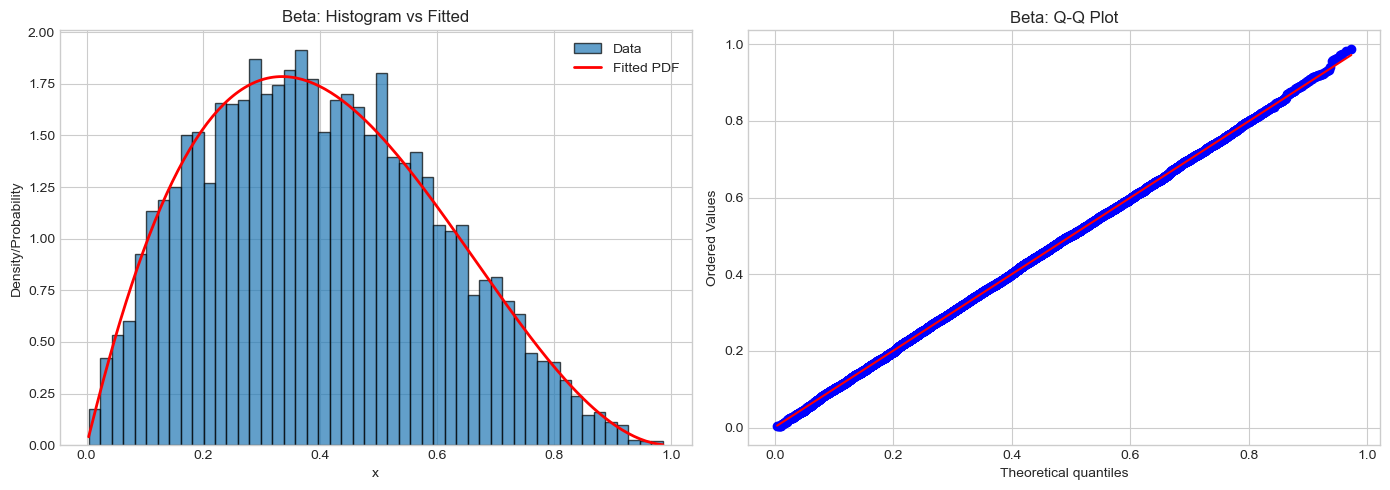

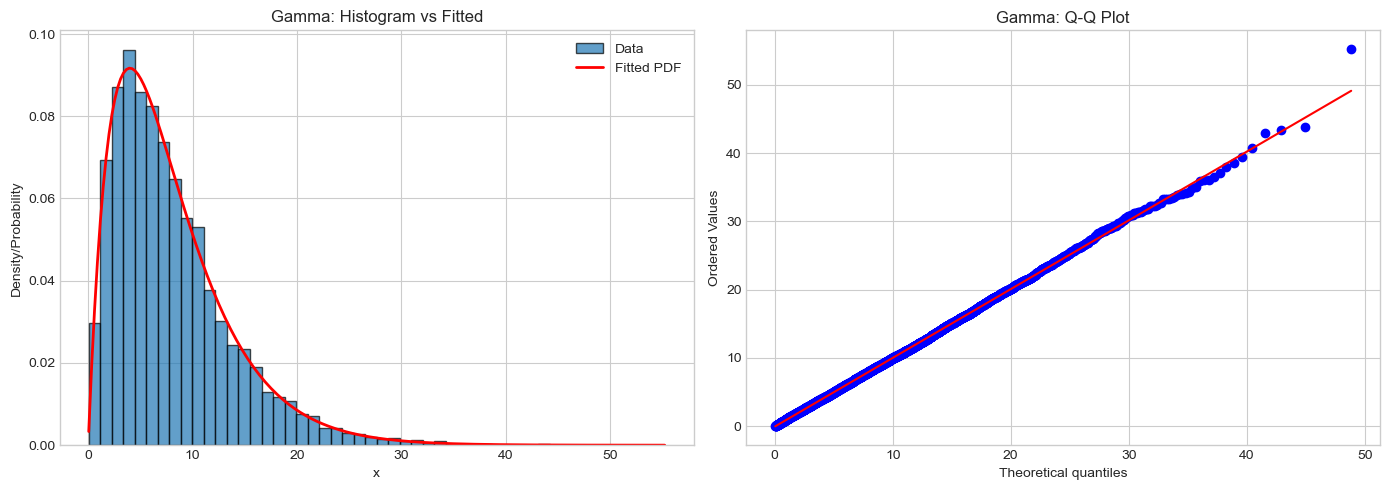


✓ Points close to diagonal line indicate good fit
✓ Deviations in tails may indicate heavy/light tail issues


In [37]:
def qq_plot_comparison(data, dist_name, dist_obj, params, title):
    """Create Q-Q plot for distribution fit assessment."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram with fitted PDF
    ax1 = axes[0]
    ax1.hist(data, bins=NBINS, density=True, alpha=0.7, edgecolor='black', label='Data')
    
    if dist_name in ['poisson', 'binom']:
        x_range = np.arange(data.min(), data.max()+1)
        pdf_fitted = dist_obj.pmf(x_range, *params)
        ax1.plot(x_range, pdf_fitted, 'ro-', linewidth=2, markersize=4, label='Fitted PMF')
    else:
        x_range = np.linspace(data.min(), data.max(), 200)
        pdf_fitted = dist_obj.pdf(x_range, *params)
        ax1.plot(x_range, pdf_fitted, 'r-', linewidth=2, label='Fitted PDF')
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('Density/Probability')
    ax1.set_title(f'{title}: Histogram vs Fitted')
    ax1.legend()
    
    # Q-Q Plot
    ax2 = axes[1]
    if dist_name not in ['poisson', 'binom']:
        stats.probplot(data, dist=dist_obj, sparams=params, plot=ax2)
        ax2.set_title(f'{title}: Q-Q Plot')
    else:
        # For discrete, use sorted data vs theoretical quantiles
        sorted_data = np.sort(data)
        n = len(sorted_data)
        theoretical = dist_obj.ppf(np.linspace(0.01, 0.99, n), *params)
        ax2.scatter(theoretical, sorted_data, alpha=0.5, s=10)
        min_val = min(theoretical.min(), sorted_data.min())
        max_val = max(theoretical.max(), sorted_data.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
        ax2.set_xlabel('Theoretical Quantiles')
        ax2.set_ylabel('Sample Quantiles')
        ax2.set_title(f'{title}: Q-Q Plot')
    
    plt.tight_layout()
    plt.show()

# Q-Q plots for each distribution
print("📊 Model Diagnostics: Q-Q Plots")
print("=" * 50)

qq_plot_comparison(X_normal, 'norm', stats.norm, (mu_mle, sigma_mle), 'Normal')
qq_plot_comparison(X_exponential, 'expon', stats.expon, (0, 1/lambda_mle), 'Exponential')
qq_plot_comparison(X_beta, 'beta', stats.beta, (alpha_beta_mle, beta_beta_mle), 'Beta')
qq_plot_comparison(X_gamma, 'gamma', stats.gamma, (alpha_gamma_mle, 0, scale_gamma_mle), 'Gamma')

print("\n✓ Points close to diagonal line indicate good fit")
print("✓ Deviations in tails may indicate heavy/light tail issues")

---
<a id='part5'></a>
# Part V: Distribution Selection Guide

## Decision Flowchart

```
What type of data do you have?
│
├── DISCRETE (counts: 0, 1, 2, ...)
│   │
│   ├── Binary outcome (0 or 1)?
│   │   └── Bernoulli
│   │
│   ├── Count of successes in n trials?
│   │   └── Binomial
│   │
│   ├── Count of events in interval?
│   │   ├── Variance ≈ Mean? → Poisson
│   │   └── Variance > Mean? → Negative Binomial
│   │
│   └── Count with no upper bound?
│       └── Poisson or Negative Binomial
│
└── CONTINUOUS
    │
    ├── Bounded [a, b]?
    │   ├── Uniform probability? → Uniform
    │   └── Varying probability? → Beta (if [0,1]) or truncated
    │
    ├── Bounded [0, ∞)?
    │   ├── Time between events? → Exponential
    │   ├── Sum of exponentials? → Gamma
    │   ├── Product of positives? → Log-Normal
    │   └── Reliability/lifetime? → Weibull
    │
    └── Unbounded (-∞, +∞)?
        ├── Symmetric, light tails? → Normal
        ├── Symmetric, heavy tails? → t-distribution
        └── Skewed? → Skew-normal or transform
```

## Quick Reference Table

In [38]:
# Display distribution selection guide
print("\n" + "=" * 100)
print(" " * 30 + "DISTRIBUTION SELECTION GUIDE")
print("=" * 100)

guide = '''
| Data Type        | Distribution    | Key Check                      | Example Use Case                |
|------------------|-----------------|--------------------------------|---------------------------------|
| Binary           | Bernoulli       | Only 0 or 1                    | Single coin flip                |
| Count (bounded)  | Binomial        | k ≤ n, fixed trials            | Defects in batch of n           |
| Count (unbounded)| Poisson         | Var ≈ Mean                     | Arrivals per hour               |
| Count (overdispersed)| Neg Binomial| Var > Mean                     | Insurance claims                |
| Time > 0         | Exponential     | Memoryless                     | Time between events             |
| Positive, skewed | Gamma           | Sum of exponentials            | Waiting for k events            |
| Proportion [0,1] | Beta            | Modeling probabilities         | Success rate estimation         |
| Symmetric        | Normal          | Bell-shaped, light tails       | Measurement errors              |
| Heavy tails      | t-distribution  | More outliers than Normal      | Financial returns               |
| Equal probability| Uniform         | Flat distribution              | Random number generation        |
'''
print(guide)


                              DISTRIBUTION SELECTION GUIDE

| Data Type        | Distribution    | Key Check                      | Example Use Case                |
|------------------|-----------------|--------------------------------|---------------------------------|
| Binary           | Bernoulli       | Only 0 or 1                    | Single coin flip                |
| Count (bounded)  | Binomial        | k ≤ n, fixed trials            | Defects in batch of n           |
| Count (unbounded)| Poisson         | Var ≈ Mean                     | Arrivals per hour               |
| Count (overdispersed)| Neg Binomial| Var > Mean                     | Insurance claims                |
| Time > 0         | Exponential     | Memoryless                     | Time between events             |
| Positive, skewed | Gamma           | Sum of exponentials            | Waiting for k events            |
| Proportion [0,1] | Beta            | Modeling probabilities         | Success rate estima

<a id='summary'></a>
# Summary & Quick Reference

## Key Formulas

| Distribution | Log-Likelihood | MLE |
|-------------|----------------|-----|
| **Normal** | $-\frac{n}{2}\log(2\pi\sigma^2) - \frac{\sum(x_i-\mu)^2}{2\sigma^2}$ | $\hat{\mu}=\bar{x}$, $\hat{\sigma}^2=\frac{1}{n}\sum(x_i-\bar{x})^2$ |
| **Exponential** | $n\log\lambda - \lambda\sum x_i$ | $\hat{\lambda} = 1/\bar{x}$ |
| **Poisson** | $\sum x_i \log\lambda - n\lambda - \sum\log(x_i!)$ | $\hat{\lambda} = \bar{x}$ |
| **Binomial** | $\sum x_i \log p + \sum(n-x_i)\log(1-p)$ | $\hat{p} = \bar{x}/n$ |
| **Beta** | $(\alpha-1)\sum\log x_i + (\beta-1)\sum\log(1-x_i) - n\log B(\alpha,\beta)$ | Numerical |
| **Gamma** | $(\alpha-1)\sum\log x_i - \sum x_i/\theta - n\alpha\log\theta - n\log\Gamma(\alpha)$ | Numerical |

## Key Takeaways

1. **Always use log-likelihood** for numerical stability
2. **Vectorize computations** for efficiency
3. **Validate with scipy.stats** built-in methods
4. **Check fit visually** with histograms and Q-Q plots
5. **Choose distributions** based on data type and properties

---

**End of Notebook**  
*Course: TTK 4260 - Multivariate Data Analysis and ML*  
*Instructor: Adil Rasheed*